In [28]:
# Test database connection

cursor = newCursor()

if isinstance(cursor, psycopg2.extensions.cursor):
    cursor.execute("SELECT version();")
    db_version = cursor.fetchone()
    print("✅ Successfully connected to PostgreSQL")
    print("Database version:", db_version[0])
else:
    print("❌ Connection failed. Please check environment configuration.")


✅ Successfully connected to PostgreSQL
Database version: PostgreSQL 16.8 on x86_64-pc-linux-gnu, compiled by gcc (GCC) 7.3.1 20180712 (Red Hat 7.3.1-17), 64-bit


In [29]:
# Featured Challenge Tables

FEATURED_TABLES = [
    "D01_transactions_2024-01",
    "D01_transactions_2024-02",
    "D01_transactions_2024-03",
    "D01_transactions_2024-04",
    "D01_transactions_2024-05",
    "D01_transactions_2024-06",
    "D01_transactions_2024-07",
    "D01_transactions_2024-08",
    "D01_transactions_2024-09",
    "D01_transactions_2024-10",
    "D01_transactions_2024-11",
    "D01_transactions_2024-12",
    "D02_payment_instruments",
    "D03_settlement_logs",
    "D04_fraud_events",
    "D05_system_outages",
    "D06_psps",
    "D07_access_channels",
    "D08_cross_border_sepa",
    "D09_macro_aggregates",
    "D10_profiles",
]

print("⭐ Featured Tables loaded:", len(FEATURED_TABLES))


⭐ Featured Tables loaded: 21


In [30]:
# Fetch tables and validate featured tables

from collections import defaultdict

c = newCursor()

q = """
SELECT table_schema, table_name
FROM information_schema.tables
WHERE table_type = 'BASE TABLE'
"""
c.execute(q)
records = c.fetchall()

user_records = [
    (schema, table) for schema, table in records
    if schema not in ("pg_catalog", "information_schema")
]

schemas_by_table = defaultdict(list)
for schema, table in user_records:
    schemas_by_table[table].append(schema)

TABLE_LOOKUP = {
    table: f"{schemas[0]}.{table}"
    for table, schemas in schemas_by_table.items()
}

print("🔎 Checking Featured Tables...\n")

found = 0
for table in FEATURED_TABLES:
    if table in TABLE_LOOKUP:
        print(f"✅ {table}")
        found += 1
    else:
        print(f"❌ {table} (not found)")

print(f"\nMatched {found} out of {len(FEATURED_TABLES)} featured tables.")


🔎 Checking Featured Tables...

✅ D01_transactions_2024-01
✅ D01_transactions_2024-02
✅ D01_transactions_2024-03
✅ D01_transactions_2024-04
✅ D01_transactions_2024-05
✅ D01_transactions_2024-06
✅ D01_transactions_2024-07
✅ D01_transactions_2024-08
✅ D01_transactions_2024-09
✅ D01_transactions_2024-10
✅ D01_transactions_2024-11
✅ D01_transactions_2024-12
✅ D02_payment_instruments
✅ D03_settlement_logs
✅ D04_fraud_events
✅ D05_system_outages
✅ D06_psps
✅ D07_access_channels
✅ D08_cross_border_sepa
✅ D09_macro_aggregates
✅ D10_profiles

Matched 21 out of 21 featured tables.


In [31]:
# List all tables

c = newCursor()

q = """
SELECT table_name
FROM information_schema.tables
"""
c.execute(q)
records = c.fetchall()

# Filter out PostgreSQL system tables
user_tables = [
    r[0] for r in records
    if not r[0].startswith("pg_")
]

if not user_tables:
    print("❌ No user tables found.")
else:
    print(f"📚 Total user tables found: {len(user_tables)}\n")
    for table in user_tables:
        print("-", table)


📚 Total user tables found: 691

- q_airport_distance
- stocks_yahoo_finance
- q_ApprovalRequest
- default
- accounts
- card2
- cards
- q_airportdistance
- channel
- audit_log_schema
- clients
- q_approvalrequest
- collations
- information_schema_catalog_name
- applicable_roles
- domain_constraints
- administrable_role_authorizations
- collation_character_set_applicability
- attributes
- character_sets
- column_udt_usage
- check_constraint_routine_usage
- column_column_usage
- check_constraints
- constraint_table_usage
- column_domain_usage
- columns
- column_privileges
- constraint_column_usage
- domain_udt_usage
- domains
- enabled_roles
- key_column_usage
- parameters
- table_privileges
- referential_constraints
- sql_features
- role_column_grants
- routine_column_usage
- routine_privileges
- role_routine_grants
- routine_routine_usage
- routine_sequence_usage
- routine_table_usage
- routines
- schemata
- sequences
- role_table_grants
- table_constraints
- triggers
- tables
- trigger

In [32]:
# Preview rows from a selected table

from psycopg2 import sql

# ✅ Choose a table
TABLE = "D04_fraud_events"  # change index e.g. FEATURED_TABLES[3]
LIMIT = 1000

if TABLE not in TABLE_LOOKUP:
    raise ValueError(f'❌ Table "{TABLE}" not found. Run Section 2 cells first.')

# Get schema + table name internally
schema, table_name = TABLE_LOOKUP[TABLE].split(".", 1)

c = newCursor()

# Safe query (handles schema + hyphenated table names correctly)
query = sql.SQL("SELECT * FROM {}.{}").format(
    sql.Identifier(schema),
    sql.Identifier(table_name)
)

c.execute(query, (LIMIT,))
rows = c.fetchall()

# Column names
colnames = [desc[0] for desc in c.description]

print(f"📄 Table: {TABLE}")
print(f"Columns ({len(colnames)}): {colnames}\n")
print(f"Showing {min(LIMIT, len(rows))} rows:\n")

# Pretty display if pandas is available
try:
    import pandas as pd
    df = pd.DataFrame(rows, columns=colnames)
    display(df)
except ImportError:
    for r in rows[:5]:
        print(r)
    if len(rows) > 5:
        print(f"\n... ({len(rows)-5} more rows)")


📄 Table: D04_fraud_events
Columns (15): ['event_id', 'transaction_id', 'event_type', 'detection_timestamp', 'risk_score', 'fraud_label', 'fraud_scenario', 'trigger_reason', 'amount_at_risk', 'amount_lost', 'detection_method', 'victim_type', 'resolution_status', 'resolution_date', 'recovery_amount']

Showing 1000 rows:



,event_id,transaction_id,event_type,detection_timestamp,risk_score,fraud_label,fraud_scenario,trigger_reason,amount_at_risk,amount_lost,detection_method,victim_type,resolution_status,resolution_date,recovery_amount
0,FRAUD_00000001,5212dd34-3c0b-497a-847d-508a2e878b90,Fraud_Alert,2024-09-19 23:05:52,0.194,0,None,Anomaly_Detected,90.9,0.0,ML_Model,Consumer,Closed_False_Positive,2024-09-24,0.0
1,FRAUD_00000002,3e740791-73e6-4ac8-a2ca-3b2f91a69442,Fraud_Alert,2024-12-31 00:01:00,0.8083,1,Card_Not_Present,High_Value_Online,83.12,83.12,ML_Model,Consumer,Closed_Confirmed_Fraud,2025-01-02,29.6
2,FRAUD_00000003,3a01ed1b-3457-4601-a6cb-bfdcaaf11a09,Fraud_Alert,2024-10-28 14:47:01,0.7567,1,Card_Not_Present,Geographic_Anomaly,30.46,30.46,Rule_Based,Consumer,Closed_Confirmed_Fraud,2024-11-04,15.18
3,FRAUD_00000004,e3afc758-4258-4806-8d3a-7ddc9e352a93,Fraud_Alert,2024-11-21 00:09:49,0.2338,0,None,Anomaly_Detected,8.69,0.0,ML_Model,Consumer,Closed_False_Positive,2024-11-23,0.0
4,FRAUD_00000005,4f961b8b-60a8-4ed1-9341-9b5d00f9d1d3,Suspicious_Activity,2024-02-16 18:42:18,0.2524,0,None,Anomaly_Detected,5.03,0.0,Customer_Report,Consumer,Closed_False_Positive,2024-02-19,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,FRAUD_00149996,b6ff9eab-0b2e-41d1-958c-c02e7a1bcebf,Fraud_Alert,2024-07-12 04:55:38,0.2588,0,None,Anomaly_Detected,55.87,0.0,Rule_Based,Consumer,Closed_False_Positive,2024-07-13,0.0
149996,FRAUD_00149997,4f07d3c6-8924-4fcc-97f9-79c4ac54e543,Fraud_Alert,2024-02-26 14:38:44,0.4318,0,None,Anomaly_Detected,88.43,0.0,ML_Model,Consumer,Closed_False_Positive,2024-02-29,0.0
149997,FRAUD_00149998,ed6aaca6-4796-4689-b6b1-8058dc5c6a0d,Fraud_Alert,2024-11-08 11:25:09,0.6751,1,Authorised_Push_Payment,Social_Engineering_Indicators,237.21,237.21,Rule_Based,Consumer,Investigating,None,0.0
149998,FRAUD_00149999,47ad684e-efe3-4adb-b716-ed755c3d7cd9,Fraud_Alert,2024-10-16 17:21:45,0.1584,0,None,Anomaly_Detected,373.11,0.0,Rule_Based,Merchant,Closed_False_Positive,2024-10-17,0.0


In [8]:
df.dtypes

event_id               object
transaction_id         object
event_type             object
detection_timestamp    object
risk_score             object
fraud_label            object
fraud_scenario         object
trigger_reason         object
amount_at_risk         object
amount_lost            object
detection_method       object
victim_type            object
resolution_status      object
resolution_date        object
recovery_amount        object
dtype: object

In [33]:
unique_resolution_status = df["resolution_status"].unique()
unique_resolution_status

array(['Closed_False_Positive', 'Closed_Confirmed_Fraud',
       'Closed_Recovered', 'Investigating'], dtype=object)

# Checking for duplicate values

In [34]:
"""
Checking for duplicate values
"""
s = df[df.duplicated()]
s

,event_id,transaction_id,event_type,detection_timestamp,risk_score,fraud_label,fraud_scenario,trigger_reason,amount_at_risk,amount_lost,detection_method,victim_type,resolution_status,resolution_date,recovery_amount


# Performing feature selection

In [35]:
df = df.drop(["fraud_scenario","resolution_date","event_id","transaction_id","detection_timestamp","amount_lost","recovery_amount"],axis = 1)
df

,event_type,risk_score,fraud_label,trigger_reason,amount_at_risk,detection_method,victim_type,resolution_status
0,Fraud_Alert,0.194,0,Anomaly_Detected,90.9,ML_Model,Consumer,Closed_False_Positive
1,Fraud_Alert,0.8083,1,High_Value_Online,83.12,ML_Model,Consumer,Closed_Confirmed_Fraud
2,Fraud_Alert,0.7567,1,Geographic_Anomaly,30.46,Rule_Based,Consumer,Closed_Confirmed_Fraud
3,Fraud_Alert,0.2338,0,Anomaly_Detected,8.69,ML_Model,Consumer,Closed_False_Positive
4,Suspicious_Activity,0.2524,0,Anomaly_Detected,5.03,Customer_Report,Consumer,Closed_False_Positive
...,...,...,...,...,...,...,...,...
149995,Fraud_Alert,0.2588,0,Anomaly_Detected,55.87,Rule_Based,Consumer,Closed_False_Positive
149996,Fraud_Alert,0.4318,0,Anomaly_Detected,88.43,ML_Model,Consumer,Closed_False_Positive
149997,Fraud_Alert,0.6751,1,Social_Engineering_Indicators,237.21,Rule_Based,Consumer,Investigating
149998,Fraud_Alert,0.1584,0,Anomaly_Detected,373.11,Rule_Based,Merchant,Closed_False_Positive


# Visualizing components of our dataframe

(0.0, 1000.0)

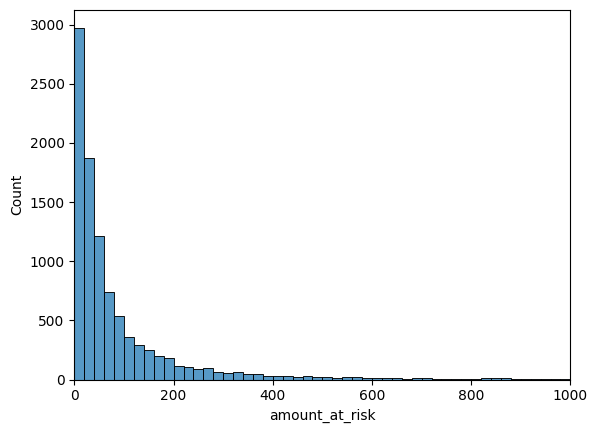

In [12]:
sample_df = df.sample(10000, random_state=42) # sampling components of our very large dataset

sns.histplot(sample_df["amount_at_risk"], bins=50, binrange=(0, 1000))
plt.xlim(0, 1000)

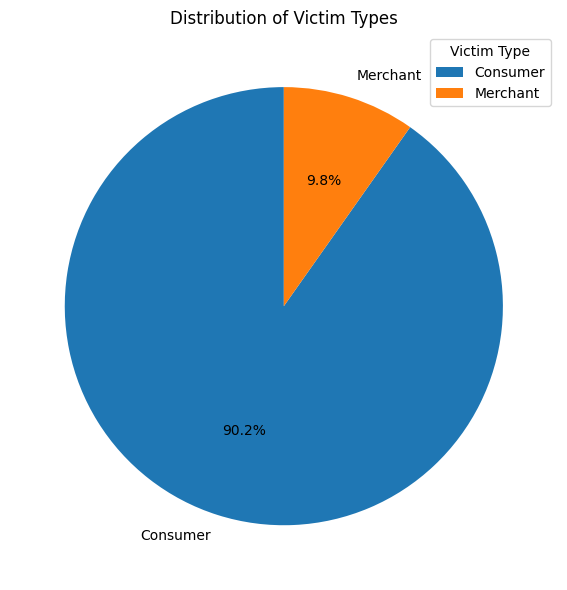

In [13]:
counts = sample_df.groupby('victim_type').size()

plt.figure(figsize=(6, 6))

counts.plot(
    kind='pie',
    autopct='%1.1f%%',     # show percentages
    startangle=90,         # rotate for better layout
    ylabel='',             # remove default ylabel
)

plt.title("Distribution of Victim Types")

plt.legend(
    title="Victim Type",
    loc="best"
)

plt.tight_layout()
plt.show()

<Axes: xlabel='trigger_reason'>

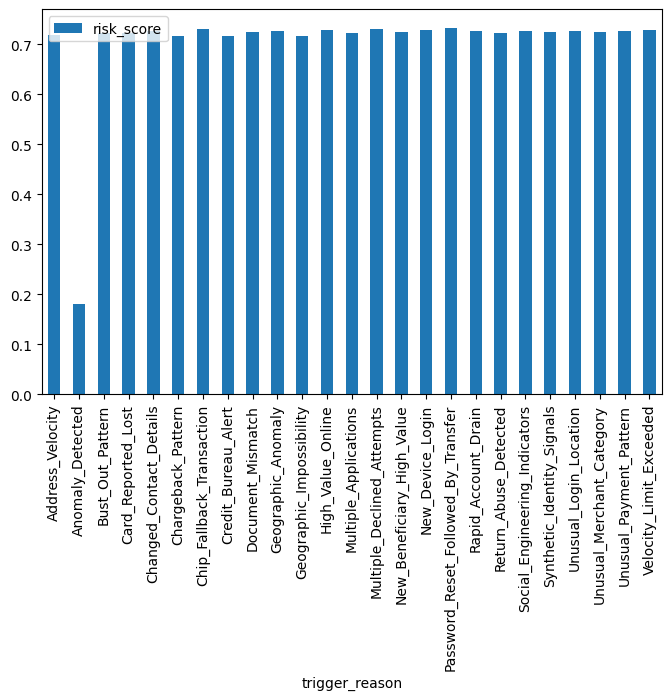

In [14]:
grouped_df = df.groupby("trigger_reason")["risk_score"].mean().reset_index()

grouped_df.plot(
    kind='bar',
    x='trigger_reason',
    y='risk_score',
    figsize=(8,5)
)



# Splitting our data

In [36]:
X = df.drop("resolution_status", axis=1)
y = df["resolution_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Performing encoding on training set


In [37]:

categorical_columns = ['event_type','trigger_reason', 'detection_method', 'victim_type']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit ONLY on training data
encoded_train = encoder.fit_transform(X_train[categorical_columns])
encoded_test = encoder.transform(X_test[categorical_columns])

In [38]:
train_encoded_df = pd.DataFrame(
    encoded_train,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X_train.index
)

test_encoded_df = pd.DataFrame(
    encoded_test,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X_test.index
)

X_train = pd.concat([X_train.drop(categorical_columns, axis=1), train_encoded_df], axis=1)
X_test = pd.concat([X_test.drop(categorical_columns, axis=1), test_encoded_df], axis=1)

In [18]:
res = X_train.corr(method='spearman')
res

/tmp/ipykernel_2030/4186266814.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  res = X_train.corr(method='spearman')


,event_type_Fraud_Alert,event_type_Suspicious_Activity,trigger_reason_Address_Velocity,trigger_reason_Anomaly_Detected,trigger_reason_Bust_Out_Pattern,trigger_reason_Card_Reported_Lost,trigger_reason_Changed_Contact_Details,trigger_reason_Chargeback_Pattern,trigger_reason_Chip_Fallback_Transaction,trigger_reason_Credit_Bureau_Alert,...,trigger_reason_Unusual_Login_Location,trigger_reason_Unusual_Merchant_Category,trigger_reason_Unusual_Payment_Pattern,trigger_reason_Velocity_Limit_Exceeded,detection_method_Bank_Staff,detection_method_Customer_Report,detection_method_ML_Model,detection_method_Rule_Based,victim_type_Consumer,victim_type_Merchant
event_type_Fraud_Alert,1.000000,-1.000000,0.024787,-0.322318,0.025722,0.035479,0.051325,0.024422,0.036576,0.023098,...,0.050496,0.103857,0.058453,0.102250,0.001734,0.000320,-0.001489,0.000196,-0.002206,0.002206
event_type_Suspicious_Activity,-1.000000,1.000000,-0.024787,0.322318,-0.025722,-0.035479,-0.051325,-0.024422,-0.036576,-0.023098,...,-0.050496,-0.103857,-0.058453,-0.102250,-0.001734,-0.000320,0.001489,-0.000196,0.002206,-0.002206
trigger_reason_Address_Velocity,0.024787,-0.024787,1.000000,-0.076904,-0.002375,-0.003276,-0.004739,-0.002255,-0.003377,-0.002133,...,-0.004662,-0.009589,-0.005397,-0.009441,-0.002060,0.006362,-0.008017,0.004774,-0.004475,0.004475
trigger_reason_Anomaly_Detected,-0.322318,0.322318,-0.076904,1.000000,-0.079803,-0.110074,-0.159237,-0.075770,-0.113478,-0.071663,...,-0.156666,-0.322221,-0.181352,-0.317235,0.001120,-0.003333,-0.000459,0.002258,0.006435,-0.006435
trigger_reason_Bust_Out_Pattern,0.025722,-0.025722,-0.002375,-0.079803,1.000000,-0.003399,-0.004917,-0.002340,-0.003504,-0.002213,...,-0.004838,-0.009950,-0.005600,-0.009796,-0.004846,0.003234,0.000727,-0.000110,0.001917,-0.001917
trigger_reason_Card_Reported_Lost,0.035479,-0.035479,-0.003276,-0.110074,-0.003399,1.000000,-0.006783,-0.003227,-0.004834,-0.003052,...,-0.006673,-0.013725,-0.007725,-0.013512,0.001910,-0.002673,0.001303,-0.000543,-0.008229,0.008229
trigger_reason_Changed_Contact_Details,0.051325,-0.051325,-0.004739,-0.159237,-0.004917,-0.006783,1.000000,-0.004669,-0.006992,-0.004416,...,-0.009654,-0.019855,-0.011175,-0.019548,0.000782,0.002505,-0.003112,0.000829,-0.002762,0.002762
trigger_reason_Chargeback_Pattern,0.024422,-0.024422,-0.002255,-0.075770,-0.002340,-0.003227,-0.004669,1.000000,-0.003327,-0.002101,...,-0.004593,-0.009448,-0.005317,-0.009301,-0.000438,-0.004374,0.000978,0.002542,-0.001465,0.001465
trigger_reason_Chip_Fallback_Transaction,0.036576,-0.036576,-0.003377,-0.113478,-0.003504,-0.004834,-0.006992,-0.003327,1.000000,-0.003147,...,-0.006879,-0.014149,-0.007963,-0.013930,-0.005059,0.000986,0.002721,-0.000342,-0.002643,0.002643
trigger_reason_Credit_Bureau_Alert,0.023098,-0.023098,-0.002133,-0.071663,-0.002213,-0.003052,-0.004416,-0.002101,-0.003147,1.000000,...,-0.004344,-0.008935,-0.005029,-0.008797,-0.000579,0.000727,-0.000423,0.000255,0.002332,-0.002332


# Plotting correlation between features

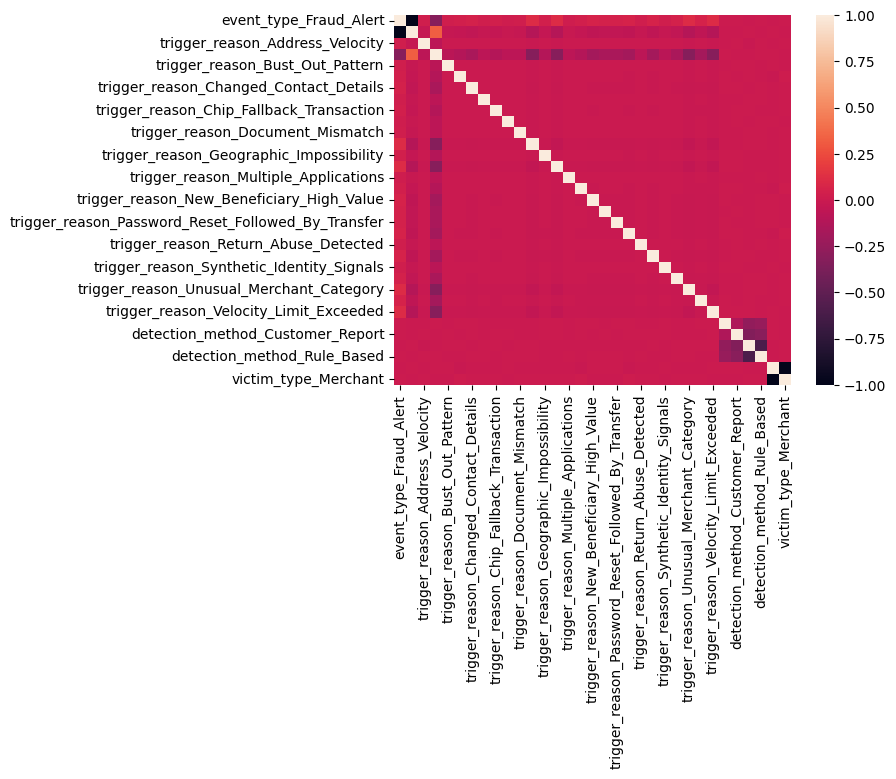

In [19]:
dataplot = sns.heatmap(res)

# Scaling our data

In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # fit the transform on our training data only
X_test_scaled = scaler.transform(X_test)

# Creating a results directory

In [40]:
path = "Model_Results/PCA"
os.makedirs(path, exist_ok=True)


# Training and evaluating our models

### Decision tree 

In [22]:
decision_tree_results = []

for n in range(1,11):
    pca = PCA(n_components=n)

    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    clf = DecisionTreeClassifier(random_state=1)
    clf.fit(X_train_pca, y_train)

    y_pred = clf.predict(X_test_pca)

    decision_tree_results.append({
        "Model Type": "Decision Tree Classifier",
        "Number_of_PCA_Components": n,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    })

decision_tree_results_df = pd.DataFrame(decision_tree_results)
decision_tree_results_df.to_csv("Model_Results/PCA/decision_tree_results.csv")

In [23]:
decision_tree_results_df

,Model Type,Number_of_PCA_Components,Accuracy,Precision,Recall,F1 Score
0,Decision Tree Classifier,1,0.839400,0.839061,0.839400,0.839222
1,Decision Tree Classifier,2,0.837833,0.840585,0.837833,0.839148
2,Decision Tree Classifier,3,0.838700,0.841427,0.838700,0.840000
3,Decision Tree Classifier,4,0.833133,0.840586,0.833133,0.836351
4,Decision Tree Classifier,5,0.830433,0.841070,0.830433,0.834783
5,Decision Tree Classifier,6,0.837633,0.840370,0.837633,0.838884
6,Decision Tree Classifier,7,0.827467,0.840729,0.827467,0.832827
7,Decision Tree Classifier,8,0.825533,0.838671,0.825533,0.830812
8,Decision Tree Classifier,9,0.832467,0.839362,0.832467,0.835442
9,Decision Tree Classifier,10,0.834867,0.839888,0.834867,0.837101


### Random forest

In [24]:
random_forest_results = []

estimators = [10,20,30,40,50]

for n in range(1, 5):
    pca = PCA(n_components=n)

    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    for estimator in estimators:
        rf_classifier = RandomForestClassifier(n_estimators=estimator, random_state=42)
        rf_classifier.fit(X_train_pca, y_train)

        y_pred = rf_classifier.predict(X_test_pca)

        random_forest_results.append({
            "Model Type": "Random Forest Classifier",
            "Number_of_PCA_Components": n,
            "n_estimators": estimator,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average="weighted"),
            "Recall": recall_score(y_test, y_pred, average="weighted"),
            "F1 Score": f1_score(y_test, y_pred, average="weighted"),
        })

random_forest_results_df = pd.DataFrame(random_forest_results)
random_forest_results_df.to_csv("Model_Results/PCA/random_forest_results.csv")

### SVM 

In [26]:
svm_results = []

for n in range(1,11):
    pca = PCA(n_components=n)

    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    svm_classifier = SVC(kernel='linear', C=1.0, random_state=42)
    svm_classifier.fit(X_train_pca, y_train)

    y_pred = svm_classifier.predict(X_test_pca)

    svm_results.append({
        "Model Type": "SVM Classifier",
        "Number_of_PCA_Components": n,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    })

svm_results_df = pd.DataFrame(svm_results)
svm_results_df.to_csv("Model_Results/PCA/svm_results.csv")

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning

### Neural network

In [43]:
neural_network_results = []

for n in range(1,5):
    pca = PCA(n_components=n)

    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    network = MLPClassifier(solver='lbfgs', alpha=1e-5,
                    hidden_layer_sizes=(5, 2), random_state=1)
    network.fit(X_train_pca, y_train)

    y_pred = network.predict(X_test_pca)

    neural_network_results.append({
        "Model Type": "Neural network Classifier",
        "Number_of_PCA_Components": n,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    })

neural_network_results_df = pd.DataFrame(neural_network_results)
neural_network_results_df.to_csv("Model_Results/PCA/neural_network_results.csv")

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning

### XGBoost

In [55]:
XGBoost_results = []

params = {
    'objective':'binary:logistic',
    'max_depth':4,
    'learning_rate':0.1,
    'n_estimators':100,
    'alpha':10
}
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test) #Encoding our target labels because XGBoost wants numerical targets
for n in range(1,5):
    pca = PCA(n_components=n)

    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    model = XGBClassifier(**params)
    
    model.fit(X_train_pca, y_train_encoded )

    y_pred = model.predict(X_test_pca)

    XGBoost_results.append({
        "Model Type": "XGBoost Classifier",
        "Number_of_PCA_Components": n,
        "Accuracy": accuracy_score(y_test_encoded, y_pred),
        "Precision": precision_score(y_test_encoded, y_pred, average="weighted"),
        "Recall": recall_score(y_test_encoded, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test_encoded, y_pred, average="weighted"),
    })

XGBoost_results_df = pd.DataFrame(XGBoost_results)
XGBoost_results_df.to_csv("Model_Results/PCA/XGBoost_results.csv")

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning

### K nearest neighbours

In [60]:
KNN_results = []

for n in range(1,5):
    pca = PCA(n_components=n)

    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    knn = KNeighborsClassifier(n_neighbors=5)
    
    knn.fit(X_train_pca, y_train)

    y_pred = knn.predict(X_test_pca)
    
    KNN_results.append({
        "Model Type": "KNN Classifier",
        "Number_of_PCA_Components": n,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred, average="weighted"),
    })

KNN_results_df = pd.DataFrame(KNN_results)
KNN_results_df.to_csv("Model_Results/PCA/KNN_results.csv")

In [62]:
KNN_results_df

,Model Type,Number_of_PCA_Components,Accuracy,Precision,Recall,F1 Score
0,KNN Classifier,1,0.868833,0.840852,0.868833,0.847926
1,KNN Classifier,2,0.868600,0.840521,0.868600,0.847856
2,KNN Classifier,3,0.868900,0.841148,0.868900,0.848393
3,KNN Classifier,4,0.868833,0.842098,0.868833,0.848891
